### ロボットアーム - Panda Gym

In [1]:
import numpy as np
import gymnasium as gym
import panda_gym
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch

from td3_algo import TD3Trainer

# 日本語フォント設定（japanize_matplotlibで文字化け防止）
import matplotlib
try:
    import japanize_matplotlib  # noqa: F401
except ImportError:
    print("japanize_matplotlib が見つかりません。必要に応じて `pip install japanize_matplotlib` を実行してください。")

# マイナス記号を正しく表示
matplotlib.rcParams['axes.unicode_minus'] = False

<div style="font-size: small;">

* ロボット: Franka Emika Panda マニピュレータの操作タスクをシミュレート。
<br>

* 観測空間:
    - すべてのタスクにグリッパの位置と速度（6値）。
    - 物体を扱うタスクでは位置・姿勢・線形/回転速度が追加（物体1つにつき12値）。
    - グリッパ開閉距離（拘束されていなければ1値）。

* 行動空間:
    - グリッパの平行移動コマンド（x, y, z の3値）。
    - グリッパ開閉コマンド（1値）。
    
* シミュレーション:
    - エージェントの1ステップあたり20タイムステップ（各2ms）。
    - インタラクション周波数は25Hz。
    - ほとんどのタスクは約2秒（50ステップ）のエピソード長。
    
* 報酬関数:
    - 既定の報酬はスパース: 目標到達（5cm 以内）なら0、それ以外は -1。
    - スパース報酬は定義が簡単だが、進捗の手掛かりが少ない。

</div>

### PandaReach-v3

<div style="font-size: small;">

* ターゲット位置は30cm × 30cm × 30cmの範囲でランダム生成され、グリッパがそこへ到達するタスク。

</div>

In [2]:
env = gym.make(
    "PandaReach-v3",
    render_mode="rgb_array",
    renderer="OpenGL",
    render_target_position=[0, 0.15, 0.25],
    render_distance=0.85,
    render_yaw=135,
    render_pitch=-20,
)

pybullet build time: Dec  5 2025 16:32:26


argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
startThreads creating 1 threads.
starting thread 0
started thread 0 
argc=5
argv[0] = --unused
argv[1] = --background_color_red=0.8745098114013672
argv[2] = --background_color_green=0.21176470816135406
argv[3] = --background_color_blue=0.1764705926179886
argv[4] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
X11 functions dynamically loaded using dlopen/dlsym OK!
X11 functions dynamically loaded using dlopen/dlsym OK!
Creating context
Created GL 3.3 context
Direct GLX rendering context obtained
Making context current
GL_VENDOR=Mesa
GL_RENDERER=llvmpipe (LLVM 20.1.2, 256 bits)
GL_VERSION=4.5 (Core Profile) Mesa 25.0.7-0ubuntu0.24.04.2
GL_SHADING_LANGUAGE_VERSION=4.50
pthread_getconcurrency()=0
Version = 4.5 (Core Profile) Mesa 25.0.7-0ubuntu0.24.04.2
Vendor = Mesa
Renderer = llvmpipe (LLVM 20.1.2, 256 bits)
b3Print


観測空間: Dict('achieved_goal': Box(-10.0, 10.0, (3,), float32), 'desired_goal': Box(-10.0, 10.0, (3,), float32), 'observation': Box(-10.0, 10.0, (6,), float32))

行動空間:  Box(-1.0, 1.0, (3,), float32)

初期状態:  ({'observation': array([ 3.8439669e-02, -2.1944723e-12,  1.9740014e-01,  0.0000000e+00,
       -0.0000000e+00,  0.0000000e+00], dtype=float32), 'achieved_goal': array([ 3.8439669e-02, -2.1944723e-12,  1.9740014e-01], dtype=float32), 'desired_goal': array([-0.08398989,  0.12119839,  0.10538146], dtype=float32)}, {'is_success': array(False)})

環境での1ステップ:  ({'observation': array([-0.00429408, -0.01640862,  0.19253877, -0.603216  , -0.26246768,
        0.3424145 ], dtype=float32), 'achieved_goal': array([-0.00429408, -0.01640862,  0.19253877], dtype=float32), 'desired_goal': array([-0.08398989,  0.12119839,  0.10538146], dtype=float32)}, -1.0, False, False, {'is_success': False})


レンダリングした環境: 


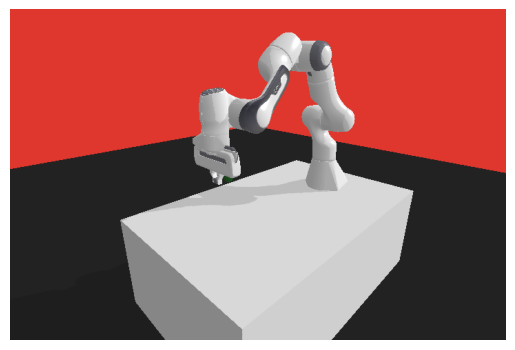

In [3]:
print('\n観測空間:', env.observation_space)
print('\n行動空間: ', env.action_space)
print('\n初期状態: ', env.reset())

# アクションは環境の期待する形状に合わせてサンプルする
sample_action = env.action_space.sample()
print('\n環境での1ステップ: ', env.step(sample_action))

print('\n\nレンダリングした環境: ')
env.reset()
plt.axis('off')
plt.imshow(env.render())
plt.show()

In [4]:
obs_shape = env.observation_space['observation'].shape[0] + \
            env.observation_space['achieved_goal'].shape[0] + \
            env.observation_space['desired_goal'].shape[0]

### 学習 - エキスパートポリシー取得

<div style="font-size: small;">

1. **初期化**:
   - ハイパーパラメータとアクター/クリティックを初期化。
   - リプレイバッファを初期化。

2. **学習ループ**:
   - エピソードを所定回数だけ繰り返す。
     - 環境をリセットして初期観測を得る。
     - エピソードが終了するまで:
       - アクター + 探索ノイズで行動を選択。
       - 行動を実行し、次状態と報酬を取得。
       - 経験 (s, a, r, s', done) をリプレイバッファへ保存。
       - HER でバッファを拡張。
       - バッファからサンプルしたミニバッチでクリティックを最適化。
       - 2回に1回の頻度でアクターを更新。
       - ターゲットアクター/クリティックをソフトアップデート。

3. **HER 拡張**:
   - 未来の状態をゴールとして再利用し、追加の学習サンプルを生成。

4. **モデル最適化**:
   - バッファに十分なサンプルがある場合にミニバッチをサンプル。
   - 2つのクリティックでターゲットQを計算し、損失を最小化。
   - クリティック2回更新につき1回アクターを更新。

5. **2つのクリティックを使う意義**:
   - min(Q1, Q2) を用いることで過大評価バイアスを抑制し、学習を安定化。
   - 2系統により過学習を抑え、局所解へのはまり込みを回避しやすくする。

</div>

In [5]:
expert = TD3Trainer(env=env, input_dims=obs_shape, agent_name='Expert', model_save_path='./Models/Expert/', 
                    exploration_period=300)

Training..:   1%|          | 6/500 [00:01<01:20,  6.13it/s]/home/shimoiyusuke/manipulator-inverse-rl/TD3/td3_algo.py:135: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  state = torch.tensor([observation], dtype=torch.float32).to(self.device)
Training..:  11%|█         | 53/500 [00:09<01:06,  6.72it/s]

Episode: 50 	 Steps: 50 	 Score: -50.0 	 Recent Avg Score: -49.0 	 Success: 1/50 (2.0%)


Training..:  20%|██        | 101/500 [00:19<01:26,  4.64it/s]

Episode: 100 	 Steps: 50 	 Score: -50.0 	 Recent Avg Score: -41.6 	 Success: 9/50 (18.0%)


Training..:  31%|███       | 153/500 [00:28<00:41,  8.41it/s]

...

Training..:  81%|████████  | 403/500 [00:50<00:08, 12.12it/s]

Episode: 400 	 Steps: 3 	 Score: -2.0 	 Recent Avg Score: -2.0 	 Success: 50/50 (100.0%)


Training..:  91%|█████████ | 453/500 [00:54<00:04, 11.37it/s]

Episode: 450 	 Steps: 3 	 Score: -2.0 	 Recent Avg Score: -1.9 	 Success: 50/50 (100.0%)


Training..: 100%|██████████| 500/500 [00:58<00:00,  8.52it/s]


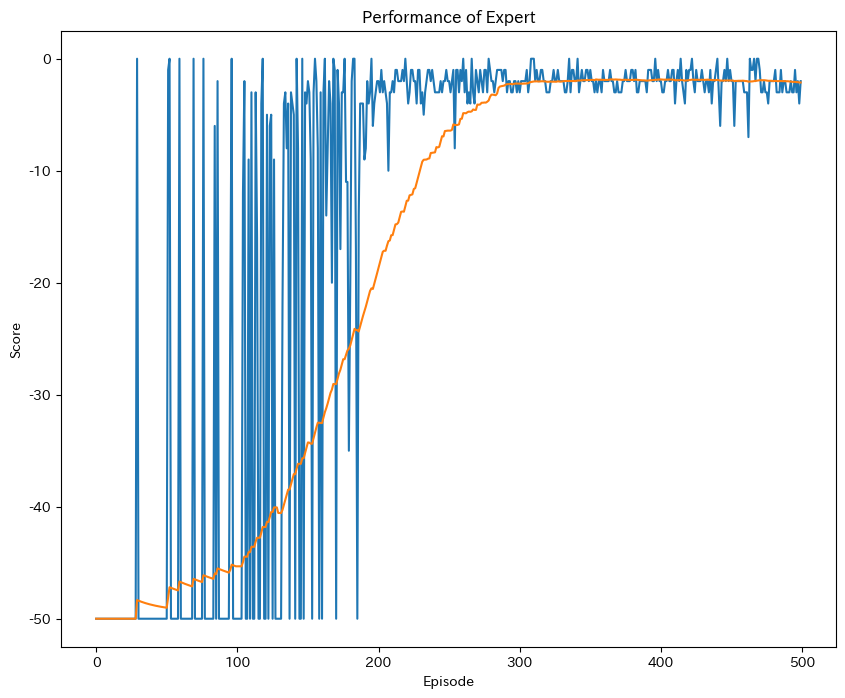

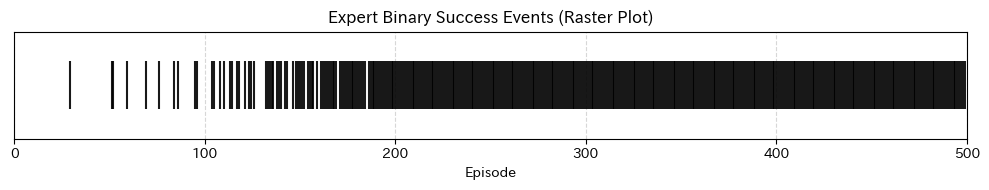

In [6]:
score_history, avg_score_history, success_history, avg_success_history = expert.td3_train(
    n_episodes=500,
    opt_steps=10,
    print_every=50,
    plot_save_path='../Results/TD3/Expert Performance.png'
)

# Plot Expert Binary Success Events (Raster Plot)
plt.figure(figsize=(10, 2))
indices = [ep for ep, val in enumerate(success_history) if val >= 0.9]
plt.eventplot([indices], lineoffsets=[0], linelengths=0.8, colors=['black'], alpha=0.9)
plt.title("Expert Binary Success Events (Raster Plot)")
plt.xlabel("Episode")
plt.yticks([])
# Use n_episodes from context if available, or just length of history
plt.xlim(0, len(success_history))
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [7]:
expert.save_model()

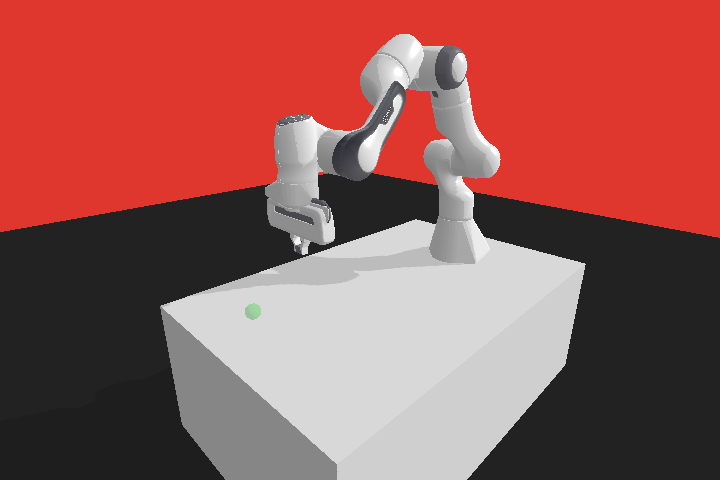

エキスパートの報酬: -2.000 - タスク: 成功


In [8]:
expert_reward, success = expert.test_model(env=env, steps=100, render_save_path='../Results/TD3/Expert Policy', fps=5)
success_str = "成功" if success else "失敗"
print(f'エキスパートの報酬: {expert_reward:.3f} - タスク: {success_str}')

In [9]:
# helper functions for evaluation
import numpy as np

def calculate_chunked_stats(history, chunk_size=50):
    if not history: return []
    chunks = [history[i:i + chunk_size] for i in range(0, len(history), chunk_size)]
    stats = []
    for i, chunk in enumerate(chunks):
        success_count = np.sum(chunk)
        failure_count = len(chunk) - success_count
        success_rate = success_count / len(chunk)
        stats.append({
            "chunk_idx": i,
            "start_episode": i * chunk_size,
            "end_episode": i * chunk_size + len(chunk),
            "success_count": success_count,
            "failure_count": failure_count,
            "success_rate": success_rate
        })
    return stats

def find_fastest_stable_model(all_results, stability_threshold=0.9, window=50):
    best_model_id = -1
    min_episodes_to_stable = float('inf')
    
    for res in all_results:
        # Calculate moving average to determine stability
        success_hist = res.get('success_history', [])
        # Check if history is sufficient for convolution
        if not success_hist or len(success_hist) < window:
            continue
            
        moving_avg = np.convolve(success_hist, np.ones(window)/window, mode='valid')
        
        # Find first index where moving avg >= threshold
        stable_indices = np.where(moving_avg >= stability_threshold)[0]
        
        if len(stable_indices) > 0:
            first_stable = stable_indices[0]
            if first_stable < min_episodes_to_stable:
                min_episodes_to_stable = first_stable
                best_model_id = res['id']
                
    return best_model_id, min_episodes_to_stable

def find_closest_to_expert(all_results, expert_history):
    if not expert_history or len(expert_history) == 0:
        return -1, float('inf')
        
    best_model_id = -1
    min_distance = float('inf')
    
    expert_curve = np.array(expert_history)
    
    for res in all_results:
        model_curve = np.array(res.get('success_history', []))
        if model_curve.size == 0:
             continue
             
        # Truncate to matching length
        min_len = min(len(expert_curve), len(model_curve))
        if min_len == 0: continue
        
        dist = np.mean((model_curve[:min_len] - expert_curve[:min_len])**2)
        
        if dist < min_distance:
            min_distance = dist
            best_model_id = res['id']
            
    return best_model_id, min_distance

def plot_intermediate_results(expert_history, all_results, n_episodes=500):
    """
    Plots Expert and current Apprentices results incrementally.
    Displays two subplots: Average Success Rate and Binary Success Raster.
    """
    from IPython.display import clear_output
    import matplotlib.pyplot as plt
    import numpy as np
    
    if not all_results and not expert_history:
        print("No results to plot yet.")
        return
    
    print(f"\n--- Plotting Results ({len(all_results)} Apprentices) ---\n")
    
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 12))
    
    # --- 1. Average Success Rate (Line Plot) ---
    ax1 = axes[0]
    
    # Expert
    if expert_history:
        exp_avg = [np.mean(expert_history[max(0, i-100):i+1]) for i in range(len(expert_history))]
        ax1.plot(exp_avg, label='Expert Baseline', color='black', linestyle='--', linewidth=2)
    
    # Apprentices
    for res in all_results:
        mid = res['id']
        if 'avg_success_history' in res and res['avg_success_history']:
             ax1.plot(res['avg_success_history'], label=f'Model {mid}', alpha=0.7)
    
    ax1.set_title("Comparison of Model Success Rates (Moving Avg)")
    ax1.set_xlabel("Episode")
    ax1.set_ylabel("Average Success Rate")
    ax1.set_xticks(np.arange(0, n_episodes + 1, 50)) # Force 50-episode ticks
    ax1.set_ylim(0, 1.05)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True)
    
    # --- 2. Binary Success Raster Plot ---
    ax2 = axes[1]
    success_events = []
    colors = []
    labels = []
    cmap = plt.get_cmap('tab10')
    
    # Expert
    if expert_history:
        indices = [ep for ep, val in enumerate(expert_history) if val >= 0.9]
        success_events.append(indices)
        colors.append('black')
        labels.append('Expert')
    
    # Apprentices
    for res in all_results:
        mid = res['id']
        if 'success_history' in res and res['success_history']:
            indices = [ep for ep, val in enumerate(res['success_history']) if val >= 0.9]
            success_events.append(indices)
            colors.append(cmap(mid % 10))
            labels.append(f'Apprentice {mid}')
            
    if success_events:
        ax2.eventplot(success_events, lineoffsets=range(len(success_events)),
                      linelengths=0.6, colors=colors, alpha=0.9)
        ax2.set_yticks(range(len(labels)))
        ax2.set_yticklabels(labels)
        ax2.set_title("Binary Success Events (Raster Plot)")
        ax2.set_xlabel("Episode")
        ax2.set_xticks(np.arange(0, n_episodes + 1, 50)) # Force 50-episode ticks
        ax2.grid(True, axis='x', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()


TD3 Expert 直後評価: 平均報酬 -2.332, 成功率 100.0%
Plotting Expert Baseline...

--- Plotting Results (0 Apprentices) ---



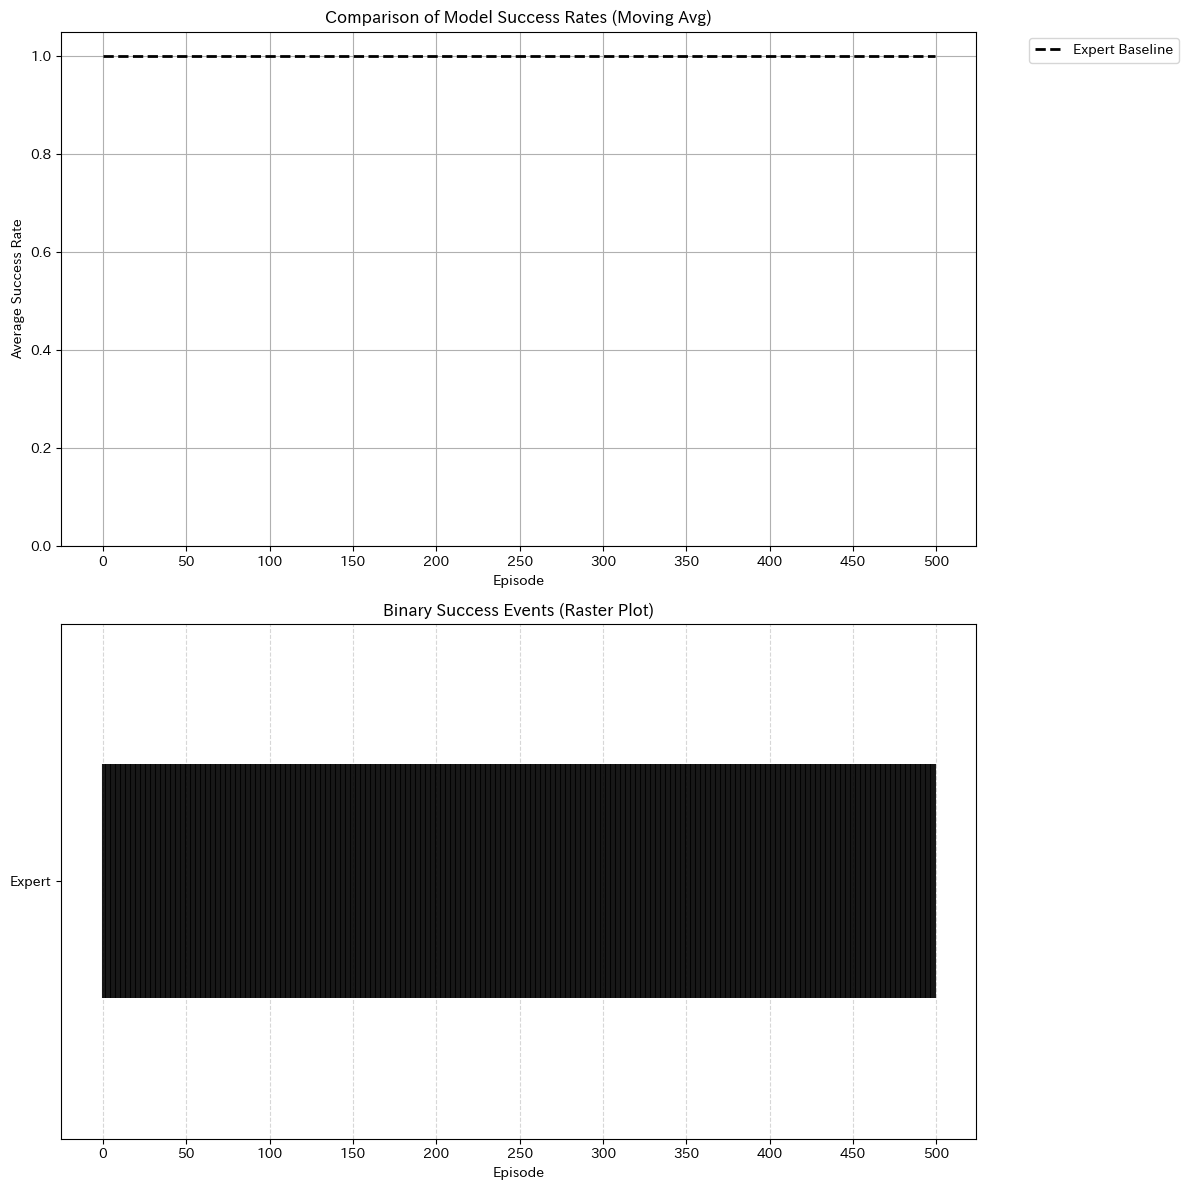

In [10]:
# 学習直後の軽量評価（平均報酬と成功率）
returns, successes = [], []
for _ in range(500):
    ep_ret, success = expert.test_model(env=env, steps=200, render_save_path=None)
    returns.append(ep_ret)
    successes.append(1 if success else 0)
mean_r = float(np.mean(returns))
succ = float(np.mean(successes) * 100)
print(f"TD3 Expert 直後評価: 平均報酬 {mean_r:.3f}, 成功率 {succ:.1f}%")

# --- Plot Expert Baseline Immediately ---
# Use the 'successes' list populated above as the expert_history
print("Plotting Expert Baseline...")
try:
    # We pass empty list for all_results since Apprentice hasn't run yet
    plot_intermediate_results(expert_history=successes, all_results=[], n_episodes=500)
except Exception as e:
    print(f"Expert plotting failed: {e}")


### IRLアルゴリズム

<div style="font-size: small;">

* 新規エージェントの学習では環境の既定報酬ではなく、IRLで推定したエキスパートの報酬関数を用いる。報酬は重み $w$ と観測特徴 $\Phi(s)$ によって与えられる。
* 特徴期待値 ($\mu(\pi)$): ポリシー $\pi$ に従うときの長期的な特徴ベクトルの期待値。
* エキスパートの特徴期待値 $\mu_E$ をモンテカルロ軌跡から推定できる。
* サンプル数 $m$ 本のエキスパート軌跡から得られる $\mu_E$ の経験的推定は次式:

$$\hat{\mu}_E = \frac{1}{m} \sum_{i=1}^m \sum_{t=0}^T \gamma^t \cdot \phi(\hat{s}^{(i)}_t)$$

</div>

In [11]:
expert = TD3Trainer(env=env, input_dims=obs_shape, agent_name='Expert', model_load_path='./Models/Expert/')

In [12]:
def compute_average_feature(agent, m=2000):
        """
        m エピソードにわたって平均特徴ベクトル（特徴期待値）と平均報酬を計算する。
        """
        with torch.inference_mode():
            feature_sum, reward_sum = None, None

            for i in tqdm(range(m), desc='特徴ベクトルと報酬を計算中'):
                reward, success, states = agent.test_model(steps=1000, save_states=True)

                # エピソード全体の特徴ベクトルの平均
                episode_mean = torch.stack(states).mean(0)

                if feature_sum is None:
                    feature_sum, reward_sum = episode_mean, reward
                else:
                    feature_sum += episode_mean
                    reward_sum += reward

            # μ̂_E = (1/m) Σ_m Σ_t (γ^t φ(ŝ^(i)_t)) （γ ≈ 1 を仮定）
            feature_sum /= m
            reward_sum /= m

            print('\n特徴期待値: ',feature_sum)
            print('\n平均報酬: ',reward_sum)

        return feature_sum, reward_sum

In [13]:
expert_feature_expectation, expert_mean_reward = compute_average_feature(expert, m=1000)   # μ_E

特徴ベクトルと報酬を計算中: 100%|██████████| 1000/1000 [00:26<00:00, 37.94it/s]


特徴期待値:  tensor([[ 2.0045e-02,  3.0247e-04,  1.6600e-01, -2.2415e-01, -5.3083e-03,
         -3.4121e-01,  2.0045e-02,  3.0247e-04,  1.6600e-01,  4.3053e-04,
          4.3815e-03,  1.4800e-01]], device='cuda:0')

平均報酬:  -2.349


### 射影法によるIRLアルゴリズム

<div style="font-size: small;">

1. **初期化:**
   - 初期ポリシー $\pi^{(0)}$ をランダムに選ぶ。
   - モンテカルロなどで特徴期待値 $\mu^{(0)}$ を計算。
   - 反復カウンタ $i = 1$ に設定。

2. **マージン計算:**
   - 現在の特徴期待値と過去ポリシー群との最大マージン $t^{(i)}$ を計算。
   - 射影法で最適な重み $w^{(i)}$ を求める。

3. **終了判定:**
   - マージン $t^{(i)} \leq \epsilon$ なら終了。

4. **IRL学習:**
   - 重み $w^{(i)}$ による報酬でMDPを定義し、RLアルゴリズムで最適ポリシー $\pi^{(i)}$ を計算。

5. **特徴期待値の更新:**
   - 新ポリシー $\pi^{(i)}$ の特徴期待値 $\mu^{(i)}$ を推定。

6. **反復更新:**
   - 反復カウンタ $i$ をインクリメント。

7. **繰り返し:**
   - 手順2へ戻り、終了条件を満たすまで繰り返す。

終了後、$\{\pi^{(i)} : i = 0, \ldots, n\}$ のポリシー列がエキスパート挙動を近似する。

</div>

In [14]:
def projection_method_algorithm(env, expert_history=None, epsilon=0.001, m=2000, n_episodes=500,
                                opt_steps=10, exploration_period=100, save_render=True, fps=5, print_every=50):
    
    feature_expectation = []
    feature_expectation_bar = []
    weights = []
    margins = []
    rewards = []
    success_rates = []
    all_results = [] 
    
    obs_shape = env.observation_space['observation'].shape[0] + \
            env.observation_space['achieved_goal'].shape[0] + \
            env.observation_space['desired_goal'].shape[0]

    max_runs = 15
    
    for i in range(max_runs):
        print(f"\n-------------------------------------- Iteration: {i} --------------------------------------\n")
        
        # Warm Start Logic: Load model from previous apprentice if available
        load_path = f'./Models/Apprentice {i}/' if i > 0 else None
        
        # exploration_period logic: If warm starting, reduce exploration? 
        # User requested 500 total episodes. 
        # If i > 0 (transfer), we might want less exploration.
        # But adhering to user request 'like Expert', we stick to function arguments.
        current_exploration = exploration_period if i == 0 else int(exploration_period * 0.5)
        
        apprentice = TD3Trainer(env=env, input_dims=obs_shape, agent_name=f'Apprentice {i+1}', 
                                model_save_path=f'./Models/Apprentice {i+1}/', 
                                model_load_path=load_path,
                                exploration_period=current_exploration)
                                
        if i > 0 and load_path:
             print(f"Warm Start: Loaded model from {load_path}")

        # Step 1: Initialization / First Run
        if i == 0:
            observation, info = env.reset()
            if isinstance(observation, dict):
                state = np.concatenate((observation['observation'], observation['achieved_goal'], observation['desired_goal']))
            else:
                state = observation
            sample_feature = torch.tensor(state, dtype=torch.float32)
            w_0 = torch.randn(sample_feature.size(0), 1).div_(torch.randn(1).norm())
            weights.append(w_0)
            
            score_hist, avg_score_hist, success_hist, avg_success_hist = apprentice.td3_train(
                n_episodes=n_episodes, opt_steps=opt_steps, 
                reward_weights=w_0, print_every=print_every, 
                plot_save_path=f'../Results/TD3/Apprentice_{i+1}_Performance.png'
            )
            apprentice_feature_expectation, apprentice_reward = compute_average_feature(agent=apprentice, m=m)
            rewards.append(apprentice_reward)
            margins.append(1.0)
            feature_expectation.append(apprentice_feature_expectation)
            print("Expert Feature Expectation:", expert_feature_expectation)
            
        else:
            # Step 2: IRL Projection
            if i == 1:
                feature_expectation_bar.append(feature_expectation[i - 1])
                weights.append((expert_feature_expectation - feature_expectation[i - 1]).view(-1, 1))
                margins.append((expert_feature_expectation - feature_expectation_bar[i - 1]).norm().item())
            else:
                A = feature_expectation_bar[i - 2]
                B = feature_expectation[i - 1] - A
                C = expert_feature_expectation - A
                numerator = (B.view(-1, 1).t() @ C.view(-1, 1))
                denominator = (B.view(-1, 1).t() @ B.view(-1, 1))
                if denominator == 0: denominator = 1e-8
                feature_expectation_bar.append(A + (numerator / denominator) * B)
                weight = (expert_feature_expectation - feature_expectation_bar[i - 1]).view(-1, 1)
                margin = (expert_feature_expectation - feature_expectation_bar[i - 1]).norm().item()
                weights.append(weight)
                margins.append(margin)
            print(f"Margin: {margins[i]}")
            if margins[i] <= epsilon:
                print(f"Converged with margin {margins[i]} <= {epsilon}")
                break

            score_hist, avg_score_hist, success_hist, avg_success_hist = apprentice.td3_train(
                n_episodes=n_episodes, opt_steps=opt_steps, 
                reward_weights=weights[-1], print_every=print_every, 
                plot_save_path=f'../Results/TD3/Apprentice_{i+1}_Performance.png'
            )
            apprentice.save_model()
            
            if save_render:
                try:
                    apprentice.test_model(steps=1000, render_save_path=f'../Results/TD3/Apprentice {i+1} Policy')
                except Exception as e:
                    print(f"Rendering failed: {e}")

            apprentice_feature_expectation, apprentice_reward = compute_average_feature(agent=apprentice, m=m)
            rewards.append(apprentice_reward)
            feature_expectation.append(apprentice_feature_expectation)
            
        # --- Live Plotting & Results Collection ---
        final_sr = np.mean(success_hist[-100:]) * 100 if len(success_hist) >= 100 else 0.0
        success_rates.append(final_sr)
        res = {
            "id": i+1,
            "success_history": success_hist,
            "avg_success_history": avg_success_hist,
            "chunk_stats": calculate_chunked_stats(success_hist, chunk_size=50)
        }
        all_results.append(res)
        try:
            plot_intermediate_results(expert_history, all_results, n_episodes=n_episodes)
        except Exception as e:
            print(f"Plotting failed: {e}")
        print(f"Apprentice {i+1} Final Avg Success Rate: {final_sr:.1f}%")
        print(f"\nDetailed Stats for Apprentice {i+1}:")
        stats = calculate_chunked_stats(success_hist, chunk_size=50)
        print(f"{'Chunk':<6} {'Range':<15} {'Success':<10} {'Fail':<10} {'Rate':<10}")
        print("-" * 60)
        for s in stats:
            range_str = f"{s['start_episode']}-{s['end_episode']}"
            print(f"{s['chunk_idx']:<6} {range_str:<15} {s['success_count']:<10} {s['failure_count']:<10} {s['success_rate']*100:>6.2f}%")
        print("")
        
    return rewards, margins, success_rates


-------------------------------------- Iteration: 0 --------------------------------------



Training..:  10%|█         | 51/500 [00:11<01:53,  3.96it/s]

Episode: 50 	 Steps: 50 	 Score: 86.2 	 Recent Avg Score: 78.2 	 Success: 5/50 (10.0%)


Training..:  20%|██        | 101/500 [00:24<01:35,  4.18it/s]

Episode: 100 	 Steps: 50 	 Score: 86.5 	 Recent Avg Score: 84.7 	 Success: 1/50 (2.0%)


...

Training..:  80%|████████  | 401/500 [01:37<00:25,  3.87it/s]

Episode: 400 	 Steps: 50 	 Score: 86.5 	 Recent Avg Score: 74.8 	 Success: 7/50 (14.0%)


Training..:  90%|█████████ | 451/500 [01:49<00:12,  4.01it/s]

Episode: 450 	 Steps: 50 	 Score: 86.0 	 Recent Avg Score: 81.4 	 Success: 3/50 (6.0%)


Training..: 100%|██████████| 500/500 [02:02<00:00,  4.10it/s]


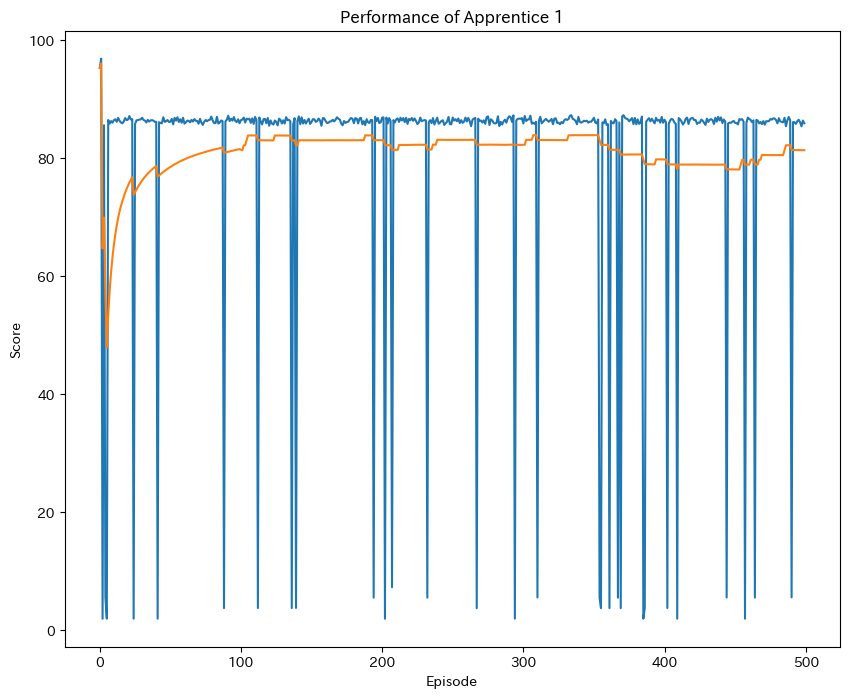

特徴ベクトルと報酬を計算中: 100%|██████████| 1000/1000 [01:40<00:00, 10.00it/s]



特徴期待値:  tensor([[-6.7339e-01, -4.1634e-01,  5.3609e-01, -2.6833e-01, -1.6572e-01,
          1.6010e-01, -6.7339e-01, -4.1634e-01,  5.3609e-01, -2.2266e-04,
         -4.5946e-03,  1.4761e-01]], device='cuda:0')

平均報酬:  -48.051
Expert Feature Expectation: tensor([[ 2.0045e-02,  3.0247e-04,  1.6600e-01, -2.2415e-01, -5.3083e-03,
         -3.4121e-01,  2.0045e-02,  3.0247e-04,  1.6600e-01,  4.3053e-04,
          4.3815e-03,  1.4800e-01]], device='cuda:0')

--- Plotting Results (1 Apprentices) ---



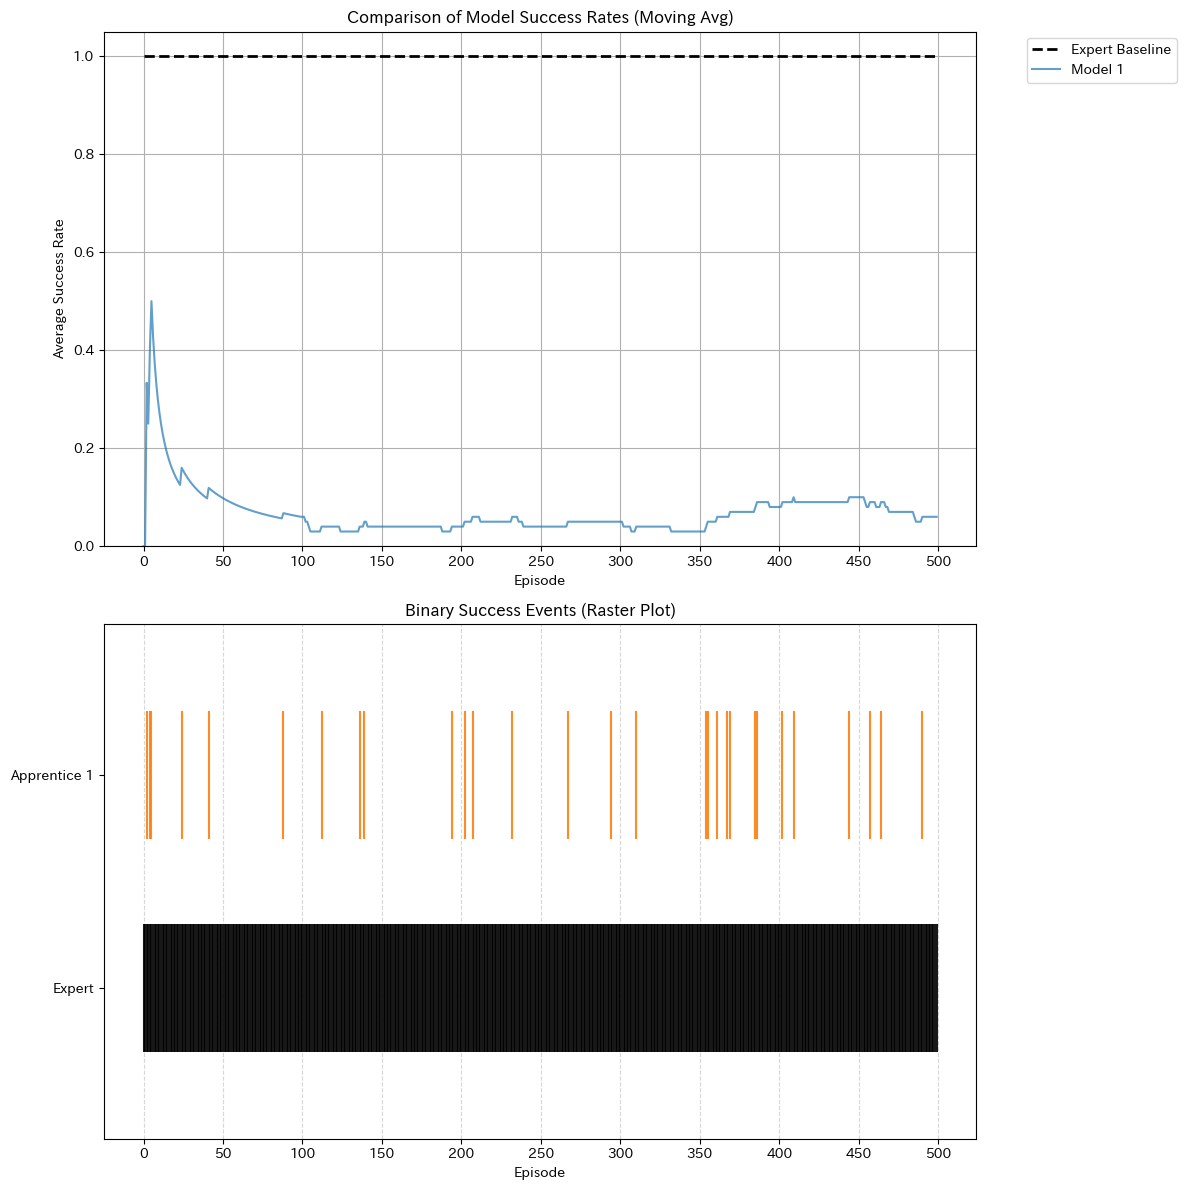

Apprentice 1 Final Avg Success Rate: 6.0%

Detailed Stats for Apprentice 1:
Chunk  Range           Success    Fail       Rate      
------------------------------------------------------------
0      0-50            5.0        45.0        10.00%
1      50-100          1.0        49.0         2.00%
2      100-150         3.0        47.0         6.00%
3      150-200         1.0        49.0         2.00%
4      200-250         3.0        47.0         6.00%
5      250-300         2.0        48.0         4.00%
6      300-350         1.0        49.0         2.00%
7      350-400         7.0        43.0        14.00%
8      400-450         3.0        47.0         6.00%
9      450-500         3.0        47.0         6.00%


-------------------------------------- Iteration: 1 --------------------------------------

Warm Start: Loaded model from ./Models/Apprentice 1/
Margin: 1.364516258239746


Training..:  10%|█         | 51/500 [00:12<01:45,  4.27it/s]

Episode: 50 	 Steps: 50 	 Score: 25.2 	 Recent Avg Score: 23.8 	 Success: 3/50 (6.0%)


Training..:  20%|██        | 101/500 [00:24<01:36,  4.12it/s]

Episode: 100 	 Steps: 50 	 Score: 25.2 	 Recent Avg Score: 24.2 	 Success: 2/50 (4.0%)


...

Training..:  80%|████████  | 401/500 [01:36<00:25,  3.83it/s]

Episode: 400 	 Steps: 50 	 Score: 25.2 	 Recent Avg Score: 22.8 	 Success: 5/50 (10.0%)


Training..:  90%|█████████ | 451/500 [01:48<00:12,  3.79it/s]

Episode: 450 	 Steps: 50 	 Score: 25.2 	 Recent Avg Score: 23.3 	 Success: 4/50 (8.0%)


Training..: 100%|██████████| 500/500 [02:00<00:00,  4.16it/s]


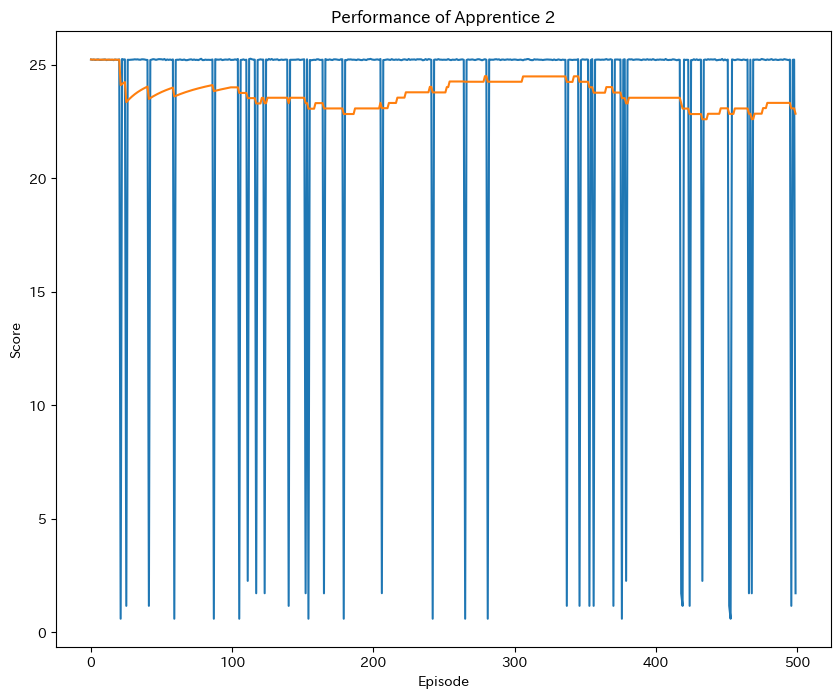

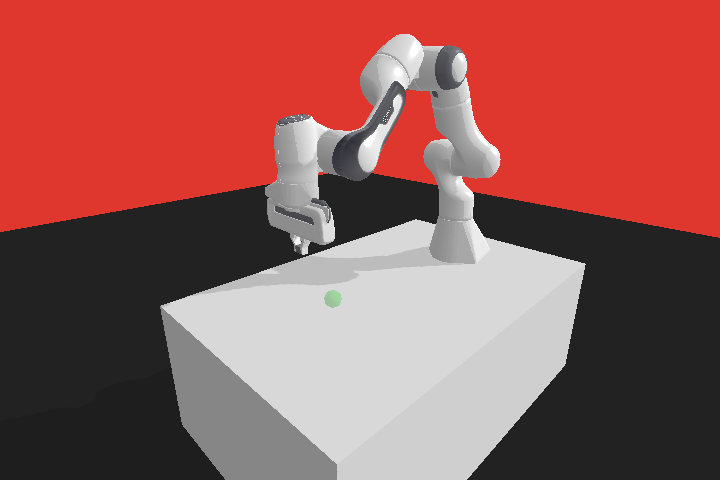

特徴ベクトルと報酬を計算中: 100%|██████████| 1000/1000 [01:41<00:00,  9.86it/s]



特徴期待値:  tensor([[-6.6839e-01, -4.1373e-01,  5.3327e-01, -2.6851e-01, -1.6883e-01,
          1.5849e-01, -6.6839e-01, -4.1373e-01,  5.3327e-01, -5.5565e-04,
          1.2431e-03,  1.4621e-01]], device='cuda:0')

平均報酬:  -47.69

--- Plotting Results (2 Apprentices) ---



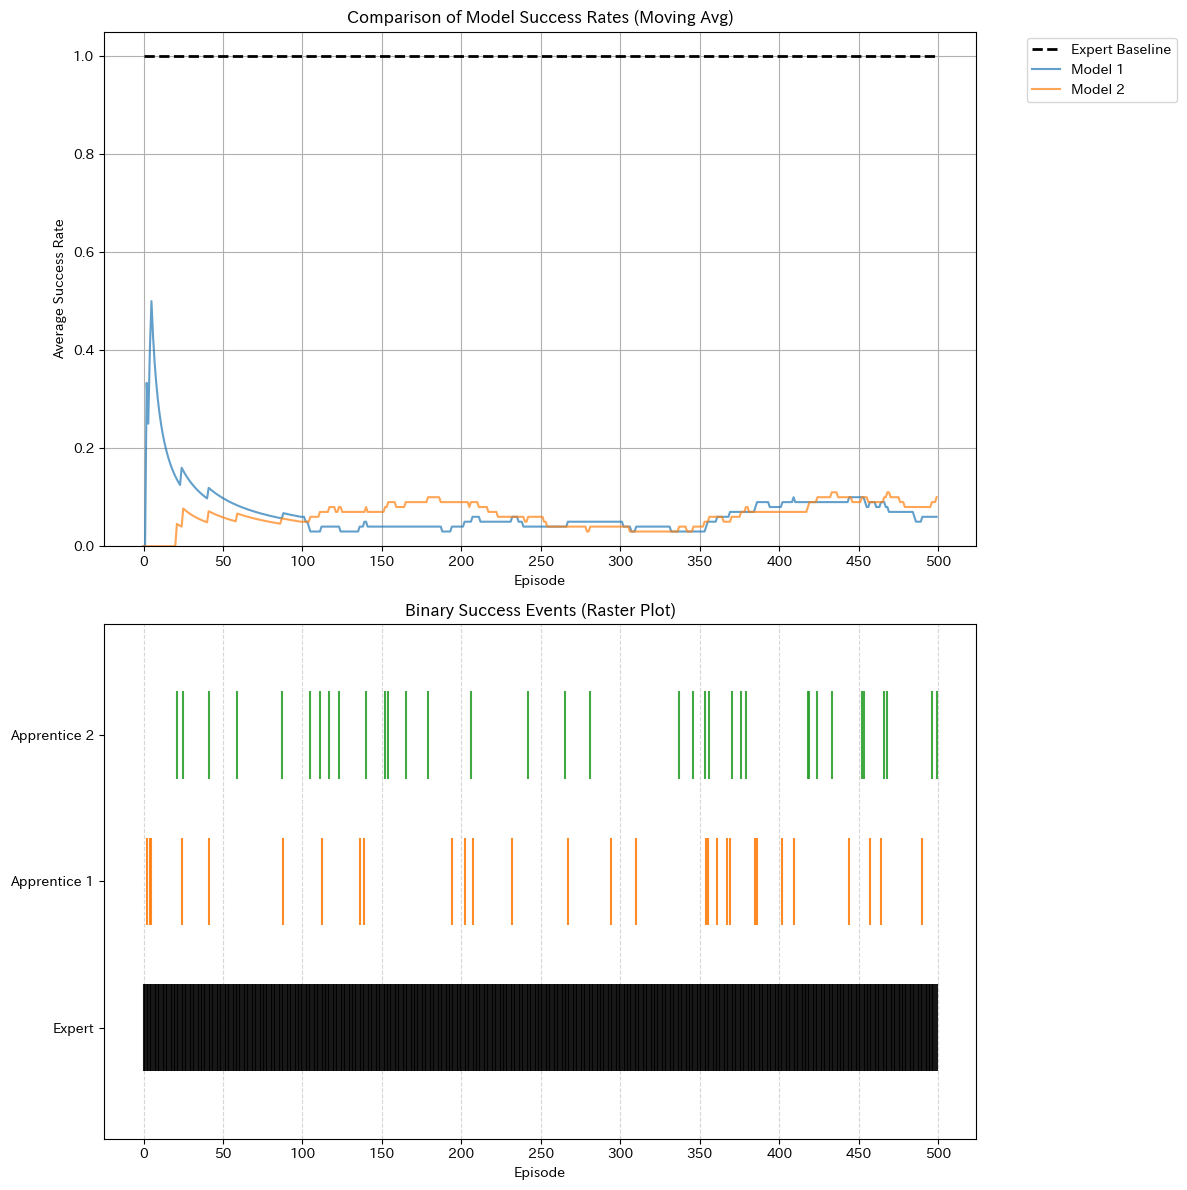

Apprentice 2 Final Avg Success Rate: 10.0%

Detailed Stats for Apprentice 2:
Chunk  Range           Success    Fail       Rate      
------------------------------------------------------------
0      0-50            3.0        47.0         6.00%
1      50-100          2.0        48.0         4.00%
2      100-150         5.0        45.0        10.00%
3      150-200         4.0        46.0         8.00%
4      200-250         2.0        48.0         4.00%
5      250-300         2.0        48.0         4.00%
6      300-350         2.0        48.0         4.00%
7      350-400         5.0        45.0        10.00%
8      400-450         4.0        46.0         8.00%
9      450-500         6.0        44.0        12.00%


-------------------------------------- Iteration: 2 --------------------------------------



FileNotFoundError: [Errno 2] No such file or directory: './Models/Apprentice 2/actor.pth'

In [15]:
# Execute IRL projection method for auto runs

exp_hist = successes if 'successes' in locals() else []

# Settings updated per user request:
# - n_episodes: 500 
# - exploration_period: 50 (10% of total) for faster convergence given warm start
rewards, margins, success_rates = projection_method_algorithm(
    env, 
    expert_history=exp_hist, 
    n_episodes=500, 
    m=1000, 
    exploration_period=100
)

overall_success_rate = float(np.mean(success_rates)) if success_rates else 0.0
print(f"Overall success rate across {len(success_rates)} apprentices: {overall_success_rate:.1f}%")

In [ ]:
# Plot apprentice rewards with 1-indexed horizontal axis
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(rewards) + 1), rewards, marker='o')
plt.title('Average Episode Reward')
plt.xlabel('Apprentice Number')
plt.ylabel('Average Episode Reward')
plt.xticks(range(1, len(rewards) + 1))  # force integer ticks starting at 1
plt.savefig("../Results/TD3/Apprentice Rewards.png")
plt.show()

In [ ]:
# Plot Binary Success Events (Raster Plot)
# Shows exact success episodes for each model in a single graph
plt.figure(figsize=(12, 8))

# Prepare data for eventplot
success_events = []
colors = []
labels = []

# Use a colormap
cmap = plt.get_cmap('tab10')

# 1. Add Expert Data first (at the bottom or top? Let's put Expert at the top -> Index 0? or Max? 
# Usually baseline is at bottom or top. Let's put Expert at index -1 (bottom) or separate color.

# Expert
if 'expert_success_history' in locals() in locals() and expert_success_history:
    indices = [ep for ep, val in enumerate(expert_success_history) if val >= 0.9]
    success_events.append(indices)
    colors.append('black')  # Expert is black
    labels.append('Expert')

# 2. Add Apprentices
if any(all_results):
    for res in all_results:
        model_id = res['id']
        hist = res['success_history']
        indices = [ep for ep, val in enumerate(hist) if val >= 0.9]
        success_events.append(indices)
        colors.append(cmap(model_id % 10))
        labels.append(f'Apprentice {model_id+1}')

# Plot
if success_events:
    plt.eventplot(success_events, lineoffsets=range(len(success_events)), 
                  linelengths=0.8, colors=colors, alpha=0.9)
    
    plt.title('Binary Success Events per Model inclusion Expert (Raster Plot)')
    plt.xlabel('Episode')
    plt.ylabel('Model')
    
    plt.yticks(range(len(labels)), labels)
    plt.ylim(-0.5, len(labels) - 0.5)
    plt.xlim(0, n_episodes)
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig("../Results/TD3/Apprentice_vs_Expert_Raster.png")
    plt.show()
else:
    print("No data to plot.")


In [ ]:
# Plot success rates to visualize progression over apprentices
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(success_rates) + 1), success_rates, marker='s', color='green')
plt.title('Apprentice Success Rate (Eval)')
plt.xlabel('Apprentice Number')
plt.ylabel('Success Rate (%)')
plt.ylim(0, 100)
plt.xticks(range(1, len(success_rates) + 1))
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig("../Results/TD3/Apprentice Success Rates.png")
plt.show()

In [ ]:
# L2 policy error plotted with 1-indexed x-axis and clear labels
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Linear scale
axes[0].plot(range(1, len(margins) + 1), margins, label="$L_2$ Policy Error", marker='o')
axes[0].set_title("$L_2$ Policy Error")
axes[0].set_xlabel("Apprentice Number")
axes[0].set_ylabel("Squared Error of Features")
axes[0].set_xticks(range(1, len(margins) + 1))

# Log scale
axes[1].plot(range(1, len(margins) + 1), margins, label="$L_2$ Policy Error", marker='o')
axes[1].set_title("$L_2$ Policy Error (Log Scale)")
axes[1].set_xlabel("Apprentice Number")
axes[1].set_ylabel("Squared Error of Features")
axes[1].set_xticks(range(1, len(margins) + 1))
axes[1].set_yscale("log")

for ax in axes:

    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend()

plt.tight_layout()
plt.savefig("../Results/TD3/Apprentice Policy Error.png")
plt.show()

<div style="font-size: small;">

### 成功率による評価

`test_model()` が環境の `info['is_success']` を集計して返すようになったので、
累積報酬に閾値を設けずに成功率を評価できる。

</div>

In [ ]:
def evaluate_agent(agent, env, episodes=10, steps=200):
    """
    エージェントを複数エピソード実行して平均報酬と成功率を計算する。
    成功判定: 環境の info['is_success'] を test_model で集計した結果を利用する。
    """
    returns = []
    successes = []
    
    for _ in range(episodes):
        ep_ret, success = agent.test_model(env=env, steps=steps, render_save_path=None)
        returns.append(ep_ret)
        successes.append(1 if success else 0)
    
    mean_return = np.mean(returns)
    std_return = np.std(returns)
    success_rate = np.mean(successes) * 100
    
    return mean_return, std_return, success_rate

# TD3 エキスパートを評価
expert_mean, expert_std, expert_sr = evaluate_agent(expert, env, episodes=10, steps=200)
print(f"TD3 Expert:")
print(f"  平均報酬: {expert_mean:.3f} ± {expert_std:.3f}")
print(f"  成功率: {expert_sr:.1f}%")